In [1]:
# import necessary cmap packages to the read in gene signatures as a dataframe
import cmapPy.pandasGEXpress.GCToo as GCToo
from cmapPy.pandasGEXpress.parse import parse
import cmapPy.pandasGEXpress.subset_gctoo as sg

# import necessary preprocessing and data visualization tools
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# import modeling tools
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

# Goal
The purpose of this project is to determine drugs treating the same indication (similar drugs) have similar effects on gene signature. The gene signatures were taken from the LINCS L1000 dataset, which is part of the [NIH LINCS L1000 project](https://lincsproject.org/LINCS/tools/workflows/find-the-best-place-to-obtain-the-lincs-l1000-data). This dataset contains gene expression profiles for thousands of perturbagens at a variety of time points, doses, and cell lines. What is unique about this dataset is that they directly measure the gene expression of 978 landmark genes and use a computational model to estimate the gene expression levels of over 10,000 other genes.

## Import Training and Validation Datasets for Individual Cell Line LRMs

In [2]:
### function to select all drug-indication pairs whose TAS is above tas cutoff
def gen_tas_datasets(data, tas_cutoffs):
    ## initialize an empty dictionary to store the separate datasets for each tas cutoffs
    data_by_tas = {}
    ## for each tas cutoff
    for tas_cutoff in tas_cutoffs:
        # select the samples whose drug1 tas and drug 2 TAS are above TAS cutoff
        drug1_above_tas = data['drug1 tas'] > tas_cutoff
        drug2_above_tas = data['drug2 tas'] > tas_cutoff
        tas_data = data[drug1_above_tas & drug2_above_tas]
        # store the data in the dictionary for that tas cutoff
        data_by_tas[tas_cutoff] = tas_data
    return data_by_tas

In [3]:
### create a list containing the names of the cell lines
cell_lines = ['MCF7', 'A375', 'PC3']

### initialize an empty dictionaries to store all of the training and validation datasets
all_train_pred = {}
all_val_pred = {}

### create a list with all of the tas cutoffs
tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

### for each cell line dataset
for cell_line in cell_lines:
    ## store the location of the training dataset
    file_path = '~/LINCS/ref_data/training_data/known_ind_only/' + cell_line + '_spearman_corrs.txt'
    ## import the training dataset for that cell line
    training_data = pd.read_csv(file_path)
    ## generate datasets at each tas cutoff
    train_tas_data = gen_tas_datasets(training_data, tas_cutoffs)
    ## store the datasets in the respective dictionary for that cell line
    all_train_pred[cell_line] = train_tas_data
    
    ## store the location of the validation dataset
    file_path = '~/LINCS/ref_data/val_data/' + cell_line + '_spearman_corrs.txt'
    ## import the validation dataset for that cell line
    val_data = pd.read_csv(file_path)
    ## generate datasets at each tas cutoff
    val_tas_data = gen_tas_datasets(val_data, tas_cutoffs)
    ## store the datasets in the respective dictionary for that cell line
    all_val_pred[cell_line] = val_tas_data

all_train_pred['MCF7'][0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman correlation,drug1 indication,drug2 indication,known indication
0,ixazomib-citrate,0.747696,carfilzomib,0.763093,0.839315,Multiple Myeloma,Multiple Myeloma,True
1,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.839315,Multiple Myeloma,Multiple Myeloma,True
2,penfluridol,0.659227,lomitapide,0.706904,0.801042,Schizophrenia,Hypercholesterolemia,False
3,lomitapide,0.706904,penfluridol,0.659227,0.801042,Hypercholesterolemia,Schizophrenia,False
6,floxuridine,0.721847,ixazomib-citrate,0.747696,0.781714,Colorectal Neoplasms,Multiple Myeloma,False


#### *d. Comparing spearman correlations across TAS cutoffs*

In [4]:
def summarize_corrs(cell_line, tas_thresholds, spearman_corrs):
    # set a grid on the histograms
    sns.set(style='whitegrid')
    
    # initialize empty list to store the running list of similar and different drugs
    corrs = []
    
    # go through each tas dataset and add a running list of all similar drugs 
    for tas in tas_thresholds:
        # get all the spearman correlations for tas cutoff
        data = spearman_corrs[tas]
        
        # store whether each pair of drugs compared for spearman correlation are share an indication
        share_indication = data['known indication']
        
        # add the spearman correlations of different drugs at tas cutoff 
        corrs.append(data.loc[~share_indication, 'spearman correlation'].values)
        # add spearman correlations of similar drugs at tas cutoff to the running list
        corrs.append(data.loc[share_indication, 'spearman correlation'].values)
    
    # create a new figure for the histograms with specified sizes
    fig, ax = plt.subplots(figsize=(10,10))
    
    # create violin plots of all spearman correlations for pairs of different drugs onto one figure
    violin_plts = ax.violinplot(dataset=corrs, showmedians=True)
    
    # set alternating facecolors based on index
    for idx, violin_plts in enumerate(violin_plts['bodies']):
        if idx % 2 == 0:
            violin_plts.set_facecolor('blue')  # even index
        else:
            violin_plts.set_facecolor('green')  # odd index
    
    # title
    ax.set_title('cell line: ' + cell_line)
    # axis labels
    ax.set_ylabel("Spearman correlations")
    # set limits on y-axis
    ax.set_ylim(-0.7, 1) 
    
    # get the current limits of the plot
    xmin, xmax = plt.xlim()
    # calculate tick positions for TAS thresholds
    tick_positions = np.linspace(xmin, xmax, num=14)
    # set xticks and labels
    ax.set_xticks(tick_positions[1:])
    ax.set_xticklabels(tas_thresholds)
    # label x-axis
    ax.set_xlabel('TAS cutoff')
    
    
    # create a legend manually with custom labels and handles
    legend_labels = ['no shared indications', 'shared indication(s)']
    ax.legend(legend_labels, loc='lower right')
    plt.show()

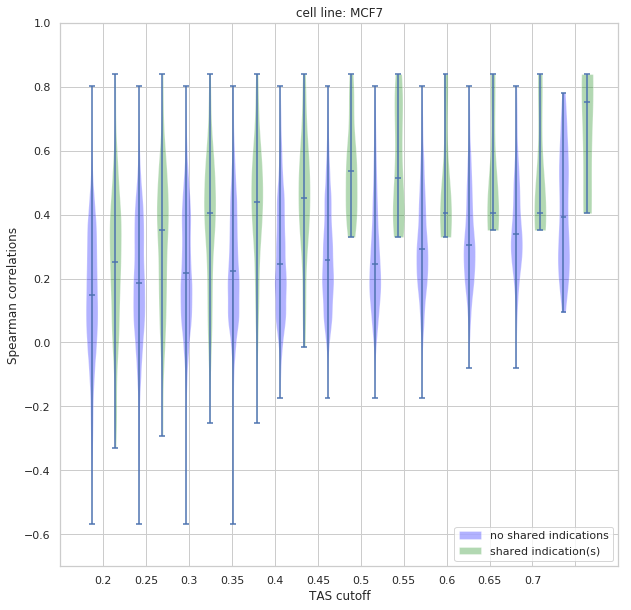

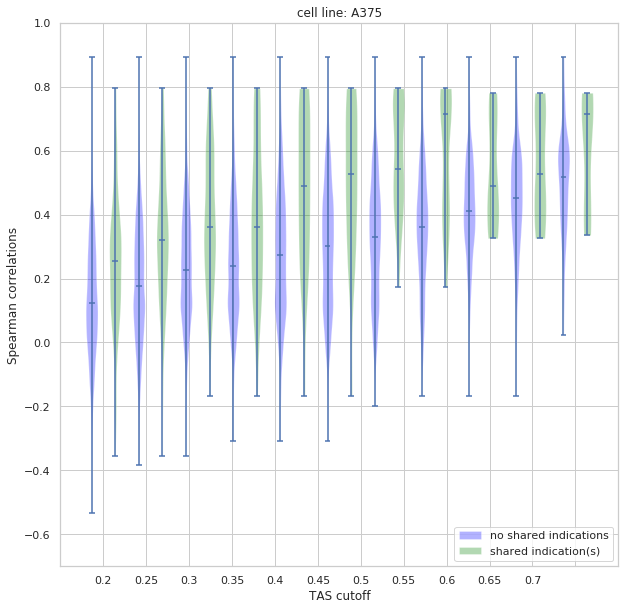

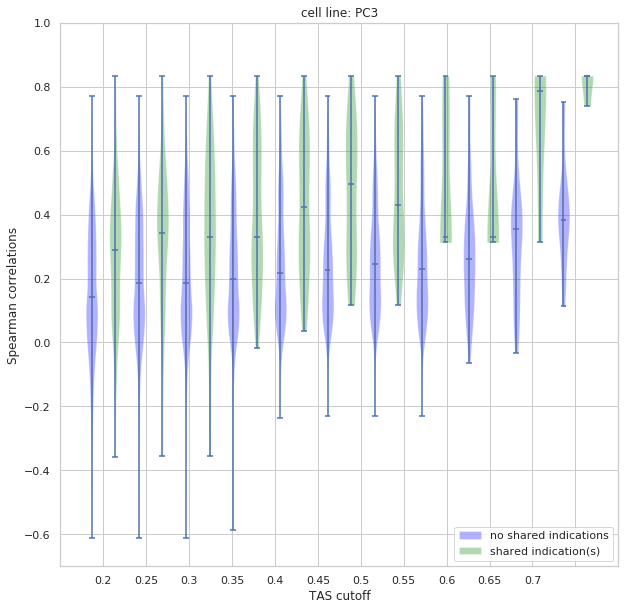

In [5]:
### for each cell line
for cell_line in cell_lines:
    ## summarize spearman correlations across all tas cutoffs in a violin plot for the training dataset for that cell line
    summarize_corrs(cell_line, tas_cutoffs, all_train_pred[cell_line])

## Generate Individual Cell Line LRMs and Predictions on Training Datasets

In [6]:
### function to create a logistic regression model for each cell line
def gen_lr_model(spearman_corrs):
    ## set seed of model
    np.random.seed(42)
    ## define inputs into the model are: drug1 tas, drug2 tas, and spearman correlation for cell line
    X = spearman_corrs.loc[:, ['drug1 tas', 'drug2 tas', 'spearman correlation']]
    ## define outputs of the model as whether drug2 treats a known indication of drug1 (0=no, 1=yes)
    y = spearman_corrs['known indication'].astype(int)
    ## train logistic regression model based on labelled input and outputs
    model = LogisticRegression(class_weight='balanced').fit(X, y)

    # get the predictions from the model
    spearman_corrs['model prediction probabilities'] = model.predict_proba(X)[:, 1]
    spearman_corrs['model predictions'] = model.predict(X)
    
    return model

In [7]:
### initialize empty dictionaries to store all of the predictions and models across all cell lines
all_models = {}

### for each cell line,
for cell_line in cell_lines:
    ## initialize empty dictionaries to store the predictions and models for cell line
    predictions = {}
    cell_line_models = {}
    
    ## iterate through each tas cutoff,
    for tas_cutoff in tas_cutoffs:
        # store the model prediction probabilities at that tas cutoff
        lr_model = gen_lr_model(all_train_pred[cell_line][tas_cutoff])
        # store the validation dataset for that cell line
        val_corrs = all_val_pred[cell_line][tas_cutoff]
        # add the model to the dictionary containing all models for that cell line
        cell_line_models[tas_cutoff] = lr_model
        
        # store the inputs to put into the model
        val_X = val_corrs[['drug1 tas', 'drug1 tas', 'spearman correlation']]
        # add a column containing the predictions for that model
        val_corrs['model prediction probabilities'] = lr_model.predict_proba(val_X)[:, 1]
        

    ## store the models in dictionary for all cell lines with key as that cell line
    all_models[cell_line] = cell_line_models

all_train_pred['MCF7'][0.6].head()

/home/katie_huang_student_uml_edu/.conda/envs/CMapPy_env/lib/python2.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/home/katie_huang_student_uml_edu/.conda/envs/CMapPy_env/lib/python2.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  del sys.path[0]
/home/katie_huang_student_uml_edu/.conda/envs/CMapPy_env/lib/python2.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.h

,drug1,drug1 tas,drug2,drug2 tas,spearman correlation,drug1 indication,drug2 indication,known indication,model prediction probabilities,model predictions
0,ixazomib-citrate,0.747696,carfilzomib,0.763093,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.882660,1
1,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.881723,1
2,penfluridol,0.659227,lomitapide,0.706904,0.801042,Schizophrenia,Hypercholesterolemia,False,0.861784,1
3,lomitapide,0.706904,penfluridol,0.659227,0.801042,Hypercholesterolemia,Schizophrenia,False,0.858426,1
6,floxuridine,0.721847,ixazomib-citrate,0.747696,0.781714,Colorectal Neoplasms,Multiple Myeloma,False,0.851477,1


In [8]:
all_val_pred['MCF7'][0.6].head()

,drug1,drug1 tas,drug2,drug2 tas,spearman correlation,drug1 indication,drug2 indication,known indication,model prediction probabilities
0,lonidamine,0.763669,ixazomib,0.791817,0.897118,Prostatic Hyperplasia|Hyperplasia,"Lymphoma, Mantle-Cell",False,0.907704
1,lonidamine,0.763669,ixazomib,0.791817,0.897118,Prostatic Hyperplasia|Hyperplasia,Lupus Nephritis,False,0.907704
2,lonidamine,0.763669,ixazomib,0.791817,0.897118,Prostatic Hyperplasia|Hyperplasia,Graft vs Host Disease,False,0.907704
3,lonidamine,0.763669,ixazomib,0.791817,0.897118,Prostatic Hyperplasia|Hyperplasia,Recurrence,False,0.907704
4,lonidamine,0.763669,ixazomib,0.791817,0.897118,Prostatic Hyperplasia|Hyperplasia,Kidney Diseases,False,0.907704


## Combined models

#### *a. Select all the drug-indication pairs shared in all cell lines (intersection)*

In [9]:
### function to generate dataset for intersection combined model
def shared_predictions(all_train_pred):
    ## initialize an empty dictionary containing all model predictions shared across all cell lines
    intersected_corrs = {}
    
    ## store the name of each individual model name and their predictions
    MCF7 = all_train_pred['MCF7']
    A375 = all_train_pred['A375']
    PC3 = all_train_pred['PC3']
    
    ## for each tas cutoff,
    for tas_cutoff in tas_cutoffs:
        # create a new dataframe containing the drug-indication pairs across both MCF7 and A375
        MFC7_A375 = pd.merge(MCF7[tas_cutoff], A375[tas_cutoff], on=['drug1', 'drug2 indication'], how='inner')

        # create a new dataframe containing the drug-indication pairs across all cell lines
        all_shared = pd.merge(MFC7_A375, PC3[tas_cutoff], on=['drug1', 'drug2 indication'], how='inner')

        # create dictionary for new labels for some columns
        new_col_names = {'model prediction probabilities_x': 'MCF7 model probabilities',
                         'model prediction probabilities_y': 'A375 model probabilities',
                         'model prediction probabilities': 'PC3 model probabilities'}
        # rename columns
        all_shared.rename(columns=new_col_names, inplace=True)

        # add another column containing the average probabilities across all cell lines
        all_shared['average probability'] = all_shared.loc[:, ['MCF7 model probabilities', 'A375 model probabilities', 'PC3 model probabilities']].mean(axis=1)

        # store this in a dictionary with that tas cutoff
        intersected_corrs[tas_cutoff] = all_shared

    return intersected_corrs

In [10]:
# generate the training data for intersection logistic regression model 
train_intersected_corrs = shared_predictions(all_train_pred)
train_intersected_corrs[0.6].head()

,drug1,drug1 tas_x,drug2_x,drug2 tas_x,spearman correlation_x,drug1 indication_x,drug2 indication,known indication_x,MCF7 model probabilities,model predictions_x,...,model predictions_y,drug1 tas,drug2,drug2 tas,spearman correlation,drug1 indication,known indication,PC3 model probabilities,model predictions,average probability
0,ixazomib-citrate,0.747696,carfilzomib,0.763093,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.882660,1,...,1,0.752297,carfilzomib,0.711043,0.834510,Multiple Myeloma,True,0.838662,1,0.838343
1,carfilzomib,0.763093,ixazomib-citrate,0.747696,0.839315,Multiple Myeloma,Multiple Myeloma,True,0.881723,1,...,0,0.711043,ixazomib-citrate,0.752297,0.834510,Multiple Myeloma,True,0.850754,1,0.739372
2,floxuridine,0.721847,ixazomib-citrate,0.747696,0.781714,Colorectal Neoplasms,Multiple Myeloma,False,0.851477,1,...,0,0.669218,ixazomib-citrate,0.752297,0.760279,Colorectal Neoplasms,False,0.818414,1,0.718410
3,ixazomib-citrate,0.747696,floxuridine,0.721847,0.781714,Multiple Myeloma,Colorectal Neoplasms,False,0.849553,1,...,1,0.752297,floxuridine,0.669218,0.760279,Multiple Myeloma,False,0.789169,1,0.810461
4,ixazomib-citrate,0.747696,bortezomib,0.826145,0.753561,Multiple Myeloma,"Lymphoma, Mantle-Cell",False,0.837924,1,...,1,0.752297,bortezomib,0.829776,0.614805,Multiple Myeloma,False,0.735855,1,0.789162


#### *b. Select all the drug-indication pairs across all cell lines (union)*

In [11]:
### function to generate dataset for union combined models across all TAS cutoffs
def gen_union_corrs(all_train_pred):
    ### initalize an empty dictionary to store the combined datasets
    union_corrs = {}
    
    ### store the individual cell line model predictions
    MCF7 = all_train_pred['MCF7']
    A375 = all_train_pred['A375']
    PC3 = all_train_pred['PC3']
    
    ### for each tas cutoffs performed
    for tas_cutoff in tas_cutoffs:
        ## get the correlations above tas cutoff and add a column containing the cell line the drug-indication pair came from
        MCF7_corrs = MCF7[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        A375_corrs = A375[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        PC3_corrs = PC3[tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]

        # create a new dataframe containing the drug-indication pairs across both MCF7 and A375
        MFC7_A375 = MCF7_corrs.merge(A375_corrs, on=['drug1', 'drug2 indication'], how='outer')

        # create a new dataframe containing the drug-indication pairs across all cell lines
        all_shared = pd.merge(MFC7_A375, PC3_corrs, on=['drug1', 'drug2 indication'], how='outer')
        
        # combine known indications into one column
        all_shared['known indication'] = all_shared['known indication'] | all_shared['known indication_x'] | all_shared['known indication_y']
        all_shared.drop(columns=['known indication_x', 'known indication_y'], axis=1, inplace=True)

        ## rename the columns
        all_shared = all_shared.rename(columns={'model prediction probabilities_x': 'MCF7',
                                             'model prediction probabilities_y': 'A375',
                                             'model prediction probabilities': 'PC3'})
        ## add this to the running dictionary for all tas cutoffs
        union_corrs[tas_cutoff] = all_shared
        
    return union_corrs

In [12]:
# generate the training data for the union models
train_union_corrs = gen_union_corrs(all_train_pred)
train_union_corrs[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3
0,ixazomib-citrate,Multiple Myeloma,0.882660,0.793708,True,0.838662
1,carfilzomib,Multiple Myeloma,0.881723,0.485640,True,0.850754
2,penfluridol,Hypercholesterolemia,0.861784,0.595653,False,NaN
3,lomitapide,Schizophrenia,0.858426,0.506476,False,NaN
4,floxuridine,Multiple Myeloma,0.851477,0.485339,False,0.818414


In [13]:
# generate the validation data for the union models
val_union_corrs = gen_union_corrs(all_val_pred)
val_union_corrs[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3
0,lonidamine,"Lymphoma, Mantle-Cell",0.907704,0.824652,False,0.882904
1,lonidamine,Lupus Nephritis,0.907704,0.824652,False,0.882904
2,lonidamine,Graft vs Host Disease,0.907704,0.824652,False,0.882904
3,lonidamine,Recurrence,0.907704,0.824652,False,0.882904
4,lonidamine,Kidney Diseases,0.907704,0.824652,False,0.882904


In [14]:
### function to get the weighted average of the combined predictions
def weighted_average(combined_predictions, weights, tas_cutoff):
    ## make a copy of the all the predictions
    weighted_predictions = combined_predictions[tas_cutoff].copy()
    ## multiply the original predictions by the specified weight for that cell line
    weighted_predictions['MCF7'] = weighted_predictions['MCF7']*weights['MCF7']
    weighted_predictions['A375'] = weighted_predictions['A375']*weights['A375']
    weighted_predictions['PC3'] = weighted_predictions['PC3']*weights['PC3']
    ## find the the sum of the weights of cell lines available (denominator)
    weighted_predictions['total_weights'] = weighted_predictions.apply(lambda row: sum(weights[cell_line] for cell_line in weights if not np.isnan(row[cell_line])), axis=1)
    ## add a column containing the weighted average across the cell lines
    weighted_predictions['model prediction probabilities'] = weighted_predictions[['MCF7', 'A375', 'PC3']].sum(axis=1)/weighted_predictions['total_weights']
    
    return weighted_predictions

In [15]:
### function to generate the weighted average of the combined predictions for union model
def gen_unweighted_union(union_corrs):
    ## initialize a dictionary to store the weighted predictions the dataset for each tas cutoff used
    ensemble_probs = {}
    ## for each tas cutoff performed
    for tas_cutoff in tas_cutoffs:
        # define the weights
        weights = {'MCF7': 1,
                   'A375': 1,
                   'PC3': 1}
        
        # get the weighted average of predicted probabilities across all cell lines
        weighted_predictions = weighted_average(union_corrs, weights, tas_cutoff)
        # store the weighted predictions in the running dictionary for all tas cutoffs
        ensemble_probs[tas_cutoff] = weighted_predictions

    return ensemble_probs

In [16]:
# generate the unweighted union model predictions for the training dataset (Drug Repurposing Hub)
train_unweighted_union = gen_unweighted_union(train_union_corrs)
train_unweighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,ixazomib-citrate,Multiple Myeloma,0.882660,0.793708,True,0.838662,3,0.838343
1,carfilzomib,Multiple Myeloma,0.881723,0.485640,True,0.850754,3,0.739372
2,penfluridol,Hypercholesterolemia,0.861784,0.595653,False,NaN,2,0.728718
3,lomitapide,Schizophrenia,0.858426,0.506476,False,NaN,2,0.682451
4,floxuridine,Multiple Myeloma,0.851477,0.485339,False,0.818414,3,0.718410


In [17]:
# generate the unweighted union model predictions for the validation dataset (AACT)
val_unweighted_union = gen_unweighted_union(val_union_corrs)
val_unweighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,lonidamine,"Lymphoma, Mantle-Cell",0.907704,0.824652,False,0.882904,3,0.871754
1,lonidamine,Lupus Nephritis,0.907704,0.824652,False,0.882904,3,0.871754
2,lonidamine,Graft vs Host Disease,0.907704,0.824652,False,0.882904,3,0.871754
3,lonidamine,Recurrence,0.907704,0.824652,False,0.882904,3,0.871754
4,lonidamine,Kidney Diseases,0.907704,0.824652,False,0.882904,3,0.871754


## Create the union ensemble model taking the weighted average using another logistic regression model

In [18]:
### function to determine the weights to apply to each individual cell line for data at one tas cutoff
def determine_weights(intersected_corrs, tas_cutoff):
    # define the input to the logistic regression model
    X = intersected_corrs[tas_cutoff].loc[:, ['MCF7 model probabilities', 'A375 model probabilities', 'PC3 model probabilities']]
    # define the output as whether they are known indications
    y = intersected_corrs[tas_cutoff]['known indication'].astype(int)
    # train a logistic regression model to determine the weights to apply to each cell line model
    combined_lr_model = LogisticRegression().fit(X, y)
    # store the weights determined for each cell line
    tas_weights = {'MCF7': combined_lr_model.coef_[0][0],
                   'A375': combined_lr_model.coef_[0][1],
                   'PC3': combined_lr_model.coef_[0][2]}
    return tas_weights, combined_lr_model

In [19]:
### function to generate the weighted average of the combined predictions for union model
def union_ensemble(intersected_corrs, union_corrs):
    ## initialize an dataframe to store the relevant information
    cell_line_weights = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3'])
    combined_lr_models = {}
    ## initialize a dictionary to store the weighted predictions the dataset for each tas cutoff used
    ensemble_probs = {}
    ## for each tas cutoff performed
    for tas_cutoff in tas_cutoffs:
        # determine the weights to apply for each cell line model
        weights, combined_model = determine_weights(intersected_corrs, tas_cutoff)
        # add the weights to the running dictionary containing all the parameters for each tas cutoff
        cell_line_weights = cell_line_weights.append(weights, ignore_index=True)
        
        # get the weighted average of predicted probabilities across all cell lines
        weighted_predictions = weighted_average(union_corrs, weights, tas_cutoff)
        # store the weighted predictions in the running dictionary for all tas cutoffs
        ensemble_probs[tas_cutoff] = weighted_predictions
        # store the model used to generate predictions
        combined_lr_models[tas_cutoff] = combined_model
    ## add the tas cutoffs to the model probabilities
    cell_line_weights['TAS cutoff'] = tas_cutoffs
    return cell_line_weights, ensemble_probs, combined_lr_models

In [20]:
tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

# create ensemble union models with the weighted average for each cell line
cell_line_weights, train_weighted_union, combined_lr_models = union_ensemble(train_intersected_corrs, train_union_corrs)
cell_line_weights.set_index('TAS cutoff', inplace=True)
cell_line_weights

,MCF7,A375,PC3
TAS cutoff,,,
0.20,1.321051,2.384962,1.513626
0.25,1.445002,1.503369,1.054974
0.30,0.985763,1.058581,0.670144
0.35,1.309273,0.067871,1.389144
0.40,1.107854,0.157585,1.431298
0.45,1.338341,-0.027662,1.278117
0.50,0.901879,0.351716,0.585314
0.55,0.112332,-0.518320,0.374277
0.60,0.223848,-0.614159,-0.276071


In [21]:
### initialize a dictionary to store the union weighted ensemble model predictions on the validation dataset across tas cutoffs
val_weighted_union = {}

### for each tas cutoff
for tas_cutoff in tas_cutoffs:
    ## store the union validation at that tas cutoff
    val_corrs = val_union_corrs[tas_cutoff]
    ## store the weights that cutoff
    weights = {'MCF7': cell_line_weights.loc[tas_cutoff, 'MCF7'],
               'A375': cell_line_weights.loc[tas_cutoff, 'A375'],
               'PC3': cell_line_weights.loc[tas_cutoff, 'PC3']}
    ## get the weighted average of predicted probabilities across all cell lines
    weighted_predictions = weighted_average(val_union_corrs, weights, tas_cutoff)
    ## store the weighted predictions in the running dictionary for all tas cutoffs
    val_weighted_union[tas_cutoff] = weighted_predictions

val_weighted_union[0.6].head()

,drug1,drug2 indication,MCF7,A375,known indication,PC3,total_weights,model prediction probabilities
0,lonidamine,"Lymphoma, Mantle-Cell",0.203188,-0.506468,False,-0.243744,-0.666382,0.820887
1,lonidamine,Lupus Nephritis,0.203188,-0.506468,False,-0.243744,-0.666382,0.820887
2,lonidamine,Graft vs Host Disease,0.203188,-0.506468,False,-0.243744,-0.666382,0.820887
3,lonidamine,Recurrence,0.203188,-0.506468,False,-0.243744,-0.666382,0.820887
4,lonidamine,Kidney Diseases,0.203188,-0.506468,False,-0.243744,-0.666382,0.820887


In [22]:
# update training model dictionary to include union ensemble models
all_train_pred['unweighted union'] = train_unweighted_union
all_train_pred['weighted union'] = train_weighted_union

# update validation model dictionary to include union ensemble models
all_val_pred['unweighted union'] = val_unweighted_union
all_val_pred['weighted union'] = val_weighted_union

## Compare number of drugs and drug-indication pairs that return true

In [23]:
### function to record the number of drugs and true drug-indication pairs at each tas cutoff
def compare_datasets(all_predictions):
    ## initialize dataframes to store the relevant information
    all_num_drugs = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])
    all_num_true = pd.DataFrame(columns=['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union'])

    ## for each tas cutoff
    for tas_cutoff in tas_cutoffs:
        ## initialize dictionaries to store the information at each 
        tas_num_drugs = {}
        tas_num_true = {}
        ## for each each model,
        for model in all_predictions.keys():
            # store the dataset for that model
            model_data = all_predictions[model][tas_cutoff]
            # store the number of drugs available in dataset
            num_drugs = len(model_data['drug1'].unique())
            # store the number of drug-indication pairs that return true
            num_true = model_data['known indication'].sum()
            # store the total number of drug-indication pairs
            total_pairs = len(model_data)
            # store the information in the dictionaries
            tas_num_drugs[model] = num_drugs
            tas_num_true[model] = num_true
        ## add the dictionaries to their respective dataframes
        all_num_drugs = all_num_drugs.append(tas_num_drugs, ignore_index=True)
        all_num_true = all_num_true.append(tas_num_true, ignore_index=True)

    ## add tas cutoffs to each dataframe
    all_num_drugs['TAS cutoff'] = tas_cutoffs
    all_num_true['TAS cutoff'] = tas_cutoffs
    
    return all_num_drugs, all_num_true

#### *a. Training dataset (known indications from RxNorm and AACT)*

In [24]:
# get the number of drugs and number of true drug-indication pairs available at each tas cutoff for training data
train_num_drugs, train_num_true = compare_datasets(all_train_pred)
train_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,300.0,300.0,309.0,441.0,441.0
1,0.25,198.0,199.0,209.0,319.0,319.0
2,0.30,149.0,134.0,146.0,237.0,237.0
3,0.35,109.0,103.0,111.0,170.0,170.0
4,0.40,89.0,77.0,84.0,132.0,132.0
5,0.45,65.0,65.0,66.0,99.0,99.0
6,0.50,47.0,58.0,52.0,79.0,79.0
7,0.55,35.0,48.0,36.0,65.0,65.0
8,0.60,26.0,37.0,23.0,46.0,46.0
9,0.65,20.0,28.0,12.0,35.0,35.0


In [25]:
train_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,371.0,396.0,412.0,521.0,521.0
1,0.25,169.0,220.0,221.0,312.0,312.0
2,0.30,105.0,140.0,111.0,196.0,196.0
3,0.35,72.0,70.0,73.0,102.0,102.0
4,0.40,58.0,46.0,56.0,70.0,70.0
5,0.45,38.0,42.0,41.0,55.0,55.0
6,0.50,24.0,32.0,26.0,42.0,42.0
7,0.55,12.0,24.0,11.0,26.0,26.0
8,0.60,11.0,16.0,9.0,16.0,16.0
9,0.65,11.0,14.0,4.0,15.0,15.0


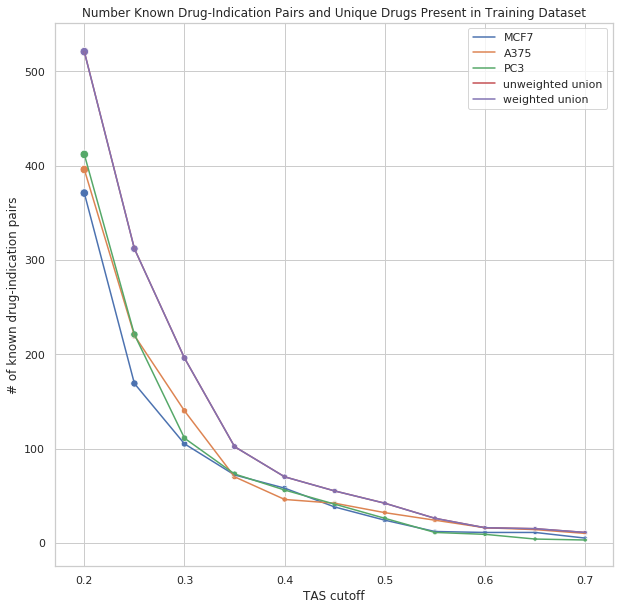

In [26]:
### set white grid
sns.set_style('whitegrid')
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
### store the names of models
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = train_num_drugs[model].astype(int).values
    sns.scatterplot(x=train_num_true['TAS cutoff'], y=train_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=train_num_true['TAS cutoff'], y=train_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Present in Training Dataset')
ax.legend()
plt.show()

#### *b. External validation (clinical indications from AACT)*

In [27]:
# get the number of drugs and number of true drug-indication pairs available at each tas cutoff for validation data
val_num_drugs, val_num_true = compare_datasets(all_val_pred)
val_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,380.0,372.0,364.0,523.0,523.0
1,0.25,261.0,267.0,262.0,399.0,399.0
2,0.30,191.0,206.0,192.0,307.0,307.0
3,0.35,140.0,156.0,151.0,225.0,225.0
4,0.40,115.0,119.0,122.0,178.0,178.0
5,0.45,96.0,101.0,90.0,143.0,143.0
6,0.50,72.0,90.0,67.0,119.0,119.0
7,0.55,55.0,80.0,53.0,99.0,99.0
8,0.60,39.0,66.0,38.0,80.0,80.0
9,0.65,29.0,47.0,25.0,58.0,58.0


In [28]:
val_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,14939.0,15540.0,15397.0,19250.0,19250.0
1,0.25,10054.0,11109.0,10162.0,13216.0,13216.0
2,0.30,7182.0,9142.0,7759.0,10720.0,10720.0
3,0.35,6139.0,7481.0,6337.0,8773.0,8773.0
4,0.40,5315.0,5717.0,5197.0,6911.0,6911.0
5,0.45,4675.0,5159.0,3793.0,6070.0,6070.0
6,0.50,2265.0,4791.0,2686.0,5287.0,5287.0
7,0.55,1305.0,4440.0,2125.0,4759.0,4759.0
8,0.60,1025.0,3963.0,1169.0,4212.0,4212.0
9,0.65,830.0,2476.0,1000.0,2669.0,2669.0


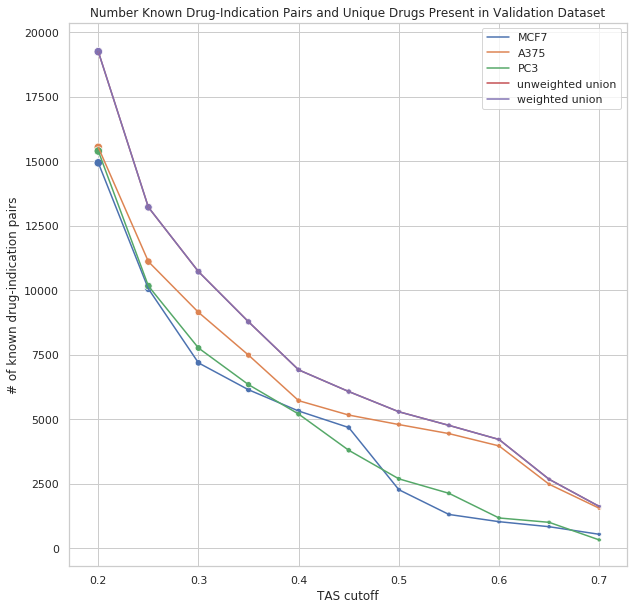

In [29]:
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = val_num_drugs[model].astype(int).values
    sns.scatterplot(x=val_num_true['TAS cutoff'], y=val_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=val_num_true['TAS cutoff'], y=val_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Present in Validation Dataset')
#ax.set_ylim(ymax=20000)
ax.legend()
plt.show()

#### *c. Intersection between training and external validation datasets*

In [30]:
### function to get the intersection dataset for all model at a tas cutoff
def shared_dataset(train_pred, val_pred, model):
    ## initialize an empty dictionary to store the intersection datasets for all models at tas cutoff
    model_intersection_pred = {}
    ## for each model,
    for tas_cutoff in tas_cutoffs:
        # store the relevant data from the training dataset for that model
        train_data = train_pred[model][tas_cutoff][['drug1', 'drug2 indication', 'model prediction probabilities']]
        # store the relevant data from the validation dataset for that model
        val_data = val_pred[model][tas_cutoff][['drug1', 'drug2 indication', 'known indication', 'model prediction probabilities']]
        # store the intersection dataset
        intersection_data = pd.merge(train_data, val_data, on=['drug1', 'drug2 indication'], how='inner', suffixes=('_train', '_val'))
        # store the datasets for the model in the dictionary for all models
        model_intersection_pred[tas_cutoff] = intersection_data
    return model_intersection_pred

In [31]:
### initialize an empty dictionary to store the intersection datasets
all_intersection_pred = {}

### for each tas cutoff
for model in all_train_pred:
    ## store the intersection datasets between training and validation datasets at that tas cutoff
    tas_pred = shared_dataset(all_train_pred, all_val_pred, model)
    ## store the results to the dictionary for all tas cutoffs
    all_intersection_pred[model] = tas_pred
all_intersection_pred['unweighted union'][0.6].head()

,drug1,drug2 indication,model prediction probabilities_train,known indication,model prediction probabilities_val
0,niclosamide,Schizophrenia,0.662269,False,0.449130
1,niclosamide,Hypercholesterolemia,0.726771,False,0.526396
2,amsacrine,Giardiasis,0.608524,False,0.455126
3,mepacrine,Precursor Cell Lymphoblastic Leukemia-Lymphoma,0.655665,False,0.598217
4,amsacrine,"Lymphoma, T-Cell, Peripheral",0.627032,False,0.733707


In [32]:
# store the number of drugs and known drug indication pairs in intersection datasets
shared_num_drugs, shared_num_true = compare_datasets(all_intersection_pred)
shared_num_drugs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,99.0,98.0,99.0,156.0,156.0
1,0.25,55.0,61.0,62.0,105.0,105.0
2,0.30,36.0,39.0,39.0,69.0,69.0
3,0.35,28.0,25.0,30.0,46.0,46.0
4,0.40,22.0,16.0,24.0,34.0,34.0
5,0.45,16.0,11.0,18.0,23.0,23.0
6,0.50,10.0,11.0,12.0,18.0,18.0
7,0.55,9.0,9.0,7.0,15.0,15.0
8,0.60,7.0,6.0,3.0,9.0,9.0
9,0.65,4.0,4.0,1.0,7.0,7.0


In [33]:
shared_num_true

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,510.0,572.0,638.0,879.0,879.0
1,0.25,222.0,246.0,192.0,383.0,383.0
2,0.30,101.0,136.0,50.0,177.0,177.0
3,0.35,69.0,80.0,33.0,106.0,106.0
4,0.40,47.0,27.0,24.0,41.0,41.0
5,0.45,38.0,22.0,15.0,32.0,32.0
6,0.50,12.0,18.0,10.0,24.0,24.0
7,0.55,4.0,12.0,5.0,18.0,18.0
8,0.60,2.0,7.0,3.0,11.0,11.0
9,0.65,1.0,4.0,0.0,4.0,4.0


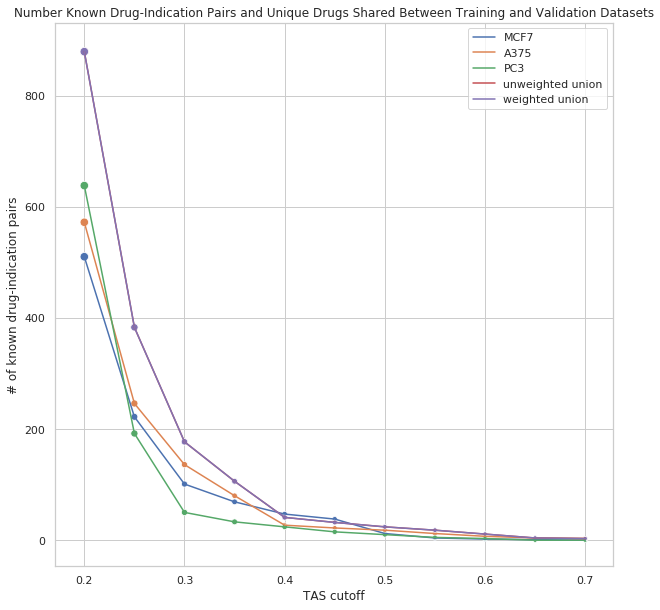

In [34]:
### create a figure with specified sizes
fig, ax = plt.subplots(figsize=(10,10))
models=['MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']

### for each model
for model in models:
    ## define the marker size as the # of true drug-indication pairs
    num_drugs = shared_num_drugs[model].astype(int).values
    sns.scatterplot(x=shared_num_true['TAS cutoff'], y=shared_num_true[model], size=num_drugs,legend=False)
    sns.lineplot(x=shared_num_true['TAS cutoff'], y=shared_num_true[model], label=model)

### add labels, title, legend
ax.set_xlabel('TAS cutoff')
ax.set_ylabel('# of known drug-indication pairs')
ax.set_title('Number Known Drug-Indication Pairs and Unique Drugs Shared Between Training and Validation Datasets')
#ax.set_ylim(ymax=1200)
ax.legend()
plt.show()

## Comparing AUCs

In [35]:
### function to obtain one ROC plot with ROC curves for all TAS thresholds
def auc_scores(all_predictions, tas_cutoff):
    ## initialize a dictionary to store the AUCs
    aucs = {}
    
    ## for each model,
    for model in all_predictions:
        # store all the predictions at that tas cutoff
        model_data = all_predictions[model][tas_cutoff]
        # store the predictions probabilities
        model_pred = model_data['model prediction probabilities']
        # store the actual results (based on clinical indication dataset)
        known_ind = model_data['known indication'].astype(int)
        # store the AUC score
        auc = roc_auc_score(known_ind, model_pred)
        # add the auc in the dictionary for that model as the key
        aucs[model] = auc
        
    return aucs

In [36]:
### intialize an empty dataframe to store of all auc scores across all tas cutoffs
columns = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
train_aucs = pd.DataFrame(columns=columns)
val_aucs = pd.DataFrame(columns=columns)

### for each tas cutoff,
for tas_cutoff in tas_cutoffs:
    ## get the aucs for each model when analysis is performed with that tas cutoff
    tas_train_aucs = auc_scores(all_train_pred, tas_cutoff)
    tas_val_aucs = auc_scores(all_val_pred, tas_cutoff)
    
    ## add this to the summary table
    train_aucs = train_aucs.append(tas_train_aucs, ignore_index=True)
    val_aucs = val_aucs.append(tas_val_aucs, ignore_index=True)

### add a column with the tas cutoffs to both dataframes
train_aucs['TAS cutoff'] = tas_cutoffs
val_aucs['TAS cutoff'] = tas_cutoffs

train_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.630816,0.671605,0.657608,0.671474,0.670868
1,0.25,0.670064,0.701110,0.682545,0.688058,0.687405
2,0.30,0.703845,0.707157,0.670903,0.692672,0.692083
3,0.35,0.754810,0.668216,0.713986,0.681480,0.671997
4,0.40,0.750860,0.733810,0.729977,0.703396,0.694418
5,0.45,0.864217,0.751242,0.768059,0.769245,0.762251
6,0.50,0.860632,0.832369,0.774970,0.831645,0.826715
7,0.55,0.814019,0.818484,0.840662,0.857957,0.603853
8,0.60,0.789091,0.742213,0.776190,0.781974,0.766193
9,0.65,0.741500,0.678622,0.839806,0.733508,0.734906


In [37]:
val_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.722022,0.748558,0.734208,0.760033,0.760577
1,0.25,0.757438,0.765368,0.728649,0.767677,0.770363
2,0.30,0.771165,0.760724,0.747206,0.782451,0.784042
3,0.35,0.768684,0.787616,0.745319,0.787090,0.769950
4,0.40,0.752702,0.780172,0.752396,0.790373,0.775496
5,0.45,0.747766,0.771942,0.758141,0.784204,0.773568
6,0.50,0.700414,0.759786,0.732901,0.763186,0.759823
7,0.55,0.707206,0.756554,0.725234,0.758148,0.694559
8,0.60,0.674692,0.659924,0.704975,0.664922,0.648920
9,0.65,0.641580,0.711225,0.682531,0.687959,0.692723


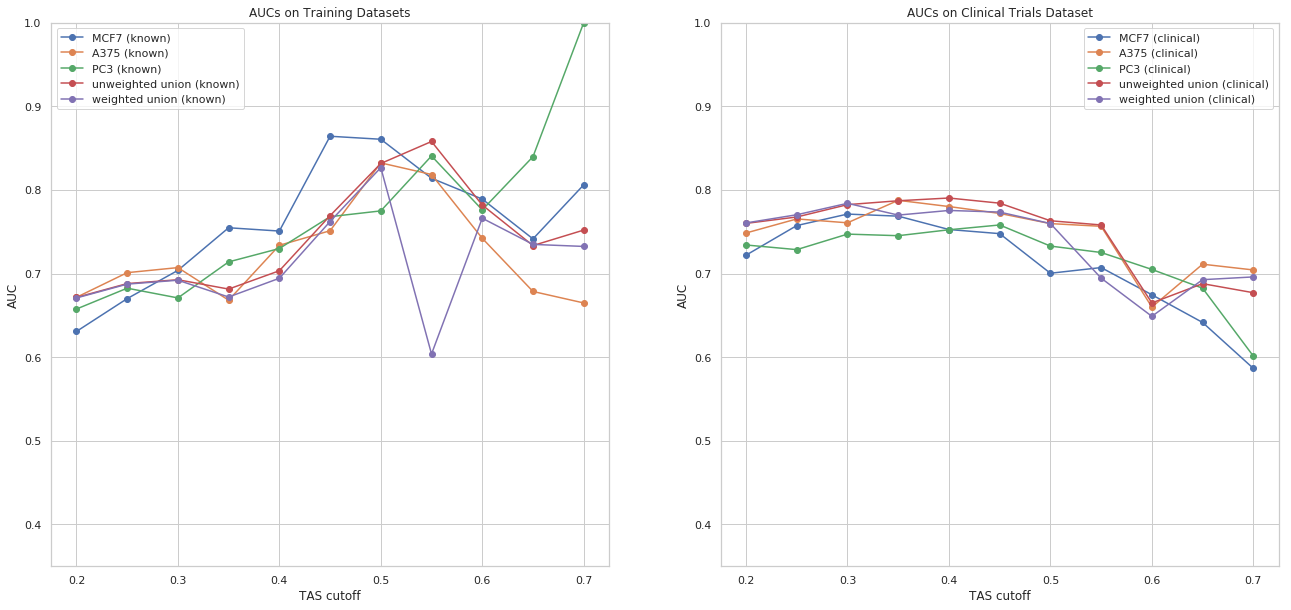

In [38]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))

### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(train_aucs['TAS cutoff'], train_aucs[model], marker='o', label=model+' (known)')
    axes[1].plot(val_aucs['TAS cutoff'], val_aucs[model], marker='o', label=model+' (clinical)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0.35, ymax=1)
axes[1].set_ylim(ymin=0.35, ymax=1)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('AUC')
axes[1].set_ylabel('AUC')

### add title
axes[0].set_title('AUCs on Training Datasets')
axes[1].set_title('AUCs on Clinical Trials Dataset')

plt.show()

In [39]:
### function to compare aucs for intersection drug-indication pairs
def intersection_aucs(intersection_pred, tas_cutoff):
    ## initialize a dictionary to store the AUCs
    train_aucs = {}
    val_aucs = {}
    
    ## for each model,
    for model in intersection_pred:
        # store all the predictions at that tas cutoff
        intersection_data = intersection_pred[model][tas_cutoff]
        # store the predictions probabilities
        train_pred = intersection_data['model prediction probabilities_train']
        val_pred = intersection_data['model prediction probabilities_val']
        # store the actual results (based on clinical indication dataset)
        known_ind = intersection_data['known indication'].astype(int)
        # store the AUC score
        tas_train_auc = roc_auc_score(known_ind, train_pred)
        tas_val_auc = roc_auc_score(known_ind, val_pred)
        # add the auc in the dictionary for that model as the key
        train_aucs[model] = tas_train_auc
        val_aucs[model] = tas_val_auc
        
    return train_aucs, val_aucs

In [40]:
### initialize an empty dataframe to store the aucs for intersection dataset across all tas cutoffs
columns = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
intersection_train_aucs = pd.DataFrame(columns=columns)
intersection_val_aucs = pd.DataFrame(columns=columns)

# redefine the tas cutoffs
int_tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

### for each tas cutoff,
for tas_cutoff in int_tas_cutoffs:
    ## get the aucs for each model when analysis is performed with that tas cutoff
    tas_train_aucs, tas_val_aucs = intersection_aucs(all_intersection_pred, tas_cutoff)
    
    ## add this to the summary table
    intersection_train_aucs = intersection_train_aucs.append(tas_train_aucs, ignore_index=True)
    intersection_val_aucs = intersection_val_aucs.append(tas_val_aucs, ignore_index=True)

### add a column with the tas cutoffs to both dataframes
intersection_train_aucs['TAS cutoff'] = int_tas_cutoffs
intersection_val_aucs['TAS cutoff'] = int_tas_cutoffs

intersection_train_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.557905,0.541884,0.587881,0.563152,0.562233
1,0.25,0.551507,0.537595,0.564741,0.557962,0.557805
2,0.30,0.570934,0.531628,0.613127,0.576357,0.575516
3,0.35,0.588966,0.504423,0.558596,0.545671,0.542287
4,0.40,0.525465,0.526337,0.505649,0.573541,0.573068
5,0.45,0.548611,0.508947,0.513353,0.581875,0.557946
6,0.50,0.637626,0.484591,0.466463,0.473359,0.482301
7,0.55,0.599315,0.529119,0.647368,0.525487,0.577606
8,0.60,0.826531,0.591052,0.683333,0.535312,0.580391


In [41]:
intersection_val_aucs

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.629284,0.626972,0.634300,0.664375,0.664580
1,0.25,0.616299,0.598090,0.594658,0.629339,0.628073
2,0.30,0.641952,0.601572,0.674697,0.684801,0.681971
3,0.35,0.652406,0.579265,0.638251,0.639200,0.661893
4,0.40,0.631616,0.554198,0.611875,0.623754,0.626903
5,0.45,0.574196,0.560245,0.520845,0.633232,0.654875
6,0.50,0.714015,0.581237,0.419512,0.611126,0.631315
7,0.55,0.604452,0.576705,0.655263,0.688813,0.521191
8,0.60,0.520408,0.533752,0.500000,0.639369,0.590533


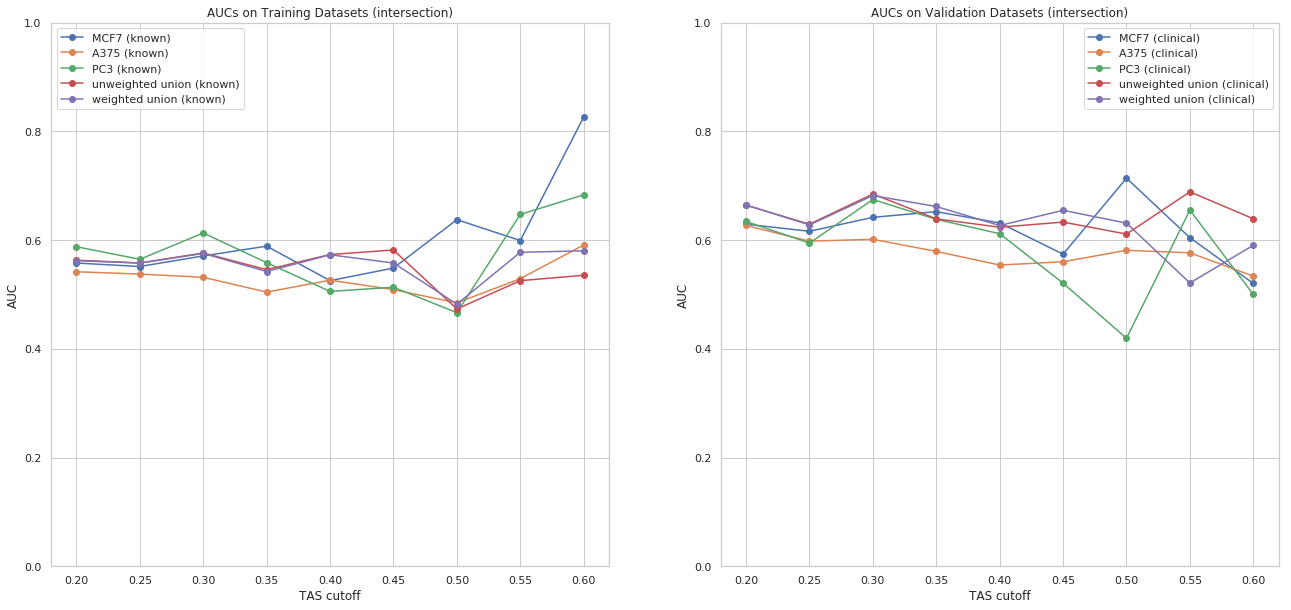

In [42]:
### create a new figure with 2 subplots side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
### for each model,
for model in models:
    ## show the AUC curves of training dataset on the left subplot
    axes[0].plot(intersection_train_aucs['TAS cutoff'], intersection_train_aucs[model], marker='o', label=model+' (known)')
    axes[1].plot(intersection_val_aucs['TAS cutoff'], intersection_val_aucs[model], marker='o', label=model+' (clinical)')

### standardize y axis limits for comparison
axes[0].set_ylim(ymin=0, ymax=1)
axes[1].set_ylim(ymin=0, ymax=1)

### add legends
axes[0].legend(loc='upper left')
axes[1].legend()

### label x axis
axes[0].set_xlabel('TAS cutoff')
axes[1].set_xlabel('TAS cutoff')
### label y axis
axes[0].set_ylabel('AUC')
axes[1].set_ylabel('AUC')

### add title
axes[0].set_title('AUCs on Training Datasets (intersection)')
axes[1].set_title('AUCs on Validation Datasets (intersection)')

plt.show()

## Comparing F1 scores

In [43]:
### function to determine the F1 scores
def get_model_metrics(all_predictions, model):
    ## initialize an empty dataframe to store the true positive rates for tas cutoff
    model_metrics = pd.DataFrame(columns=['precision', 'recall', 'F1', 'fraction true'])
    
    ## store the tas cutoffs
    tas_cutoffs = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
    
    ## for each tas cutoff,
    for tas_cutoff in tas_cutoffs:
        # store the data at that tas cutoff for that model
        model_data = all_predictions[model][tas_cutoff]
        # store the model predictions at that tas cutoff as binary output
        model_pred = (model_data['model prediction probabilities'] > 0.5).astype(int)
        # store the correct labels
        actual = model_data['known indication']
        
        # calculate the precision
        precision = precision_score(model_pred, actual)
        # calculate the recall
        recall = recall_score(model_pred, actual)
        # calculate the F1 score
        F1 = f1_score(model_pred, actual)
        # calculate the percentage of false negatives
        fraction_true = actual.sum()/float(len(actual)) * 100
        
        # store the metrics in a dictionary
        tas_metrics = {'precision': precision,
                       'recall': recall,
                       'F1': F1,
                       'fraction true': fraction_true}
        # add the results to the dataframe for all tas cutoffs
        model_metrics = model_metrics.append(tas_metrics, ignore_index=True)
        
    return model_metrics

In [44]:
### function to create dictionaries for training and validation data for a particular metric across all models
def summarize_metrics(all_train_pred, all_val_pred):
    ### store the names of columns of dataframe
    column_names = ['TAS cutoff', 'MCF7', 'A375', 'PC3', 'unweighted union', 'weighted union']
    ### create dictionaries to store all the dataframes
    train_metrics = {'precision': pd.DataFrame(columns=column_names),
                     'recall': pd.DataFrame(columns=column_names),
                     'F1': pd.DataFrame(columns=column_names),
                     'fraction true': pd.DataFrame(columns=column_names)}

    val_metrics = {'precision': pd.DataFrame(columns=column_names),
                   'recall': pd.DataFrame(columns=column_names),
                   'F1': pd.DataFrame(columns=column_names),
                   'fraction true': pd.DataFrame(columns=column_names)}
                   
    ### iterate through each dataframe
    for metric in train_metrics:
        ## add the tas cutoffs
        train_metrics[metric]['TAS cutoff'] = tas_cutoffs
        val_metrics[metric]['TAS cutoff'] = tas_cutoffs

    ### iterate through each model,
    for model in all_train_pred:
        ## and store the metrics for that model across all tas cutoffs
        train_model_metrics = get_model_metrics(all_train_pred, model)
        val_model_metrics = get_model_metrics(all_val_pred, model)
        
        ## for each metric
        for metric in train_model_metrics:
            # store the data for this metric in the respective dataframe for that model
            train_metrics[metric][model] = train_model_metrics[metric]
            val_metrics[metric][model] = val_model_metrics[metric]

    return train_metrics, val_metrics

In [49]:
# get the summary metrics for all the training and validation datasets
train_metrics, val_metrics = summarize_metrics(all_train_pred, all_val_pred)
train_metrics['fraction true']

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,0.545765,0.593001,0.590986,0.468281,0.468281
1,0.25,0.525465,0.701016,0.650996,0.504397,0.504397
2,0.30,0.540930,0.850909,0.603786,0.532204,0.532204
3,0.35,0.642570,0.742154,0.690112,0.488178,0.488178
4,0.40,0.837182,0.858209,0.900611,0.541084,0.541084
5,0.45,0.936653,1.073345,1.094501,0.705671,0.705671
6,0.50,1.230138,0.997195,1.129944,0.856095,0.856095
7,0.55,1.184600,1.049410,0.988320,0.791959,0.791959
8,0.60,1.877133,1.311475,2.097902,0.992556,0.992556
9,0.65,2.835052,1.958042,3.738318,1.547988,1.547988


In [50]:
val_metrics['fraction true']

,TAS cutoff,MCF7,A375,PC3,unweighted union,weighted union
0,0.20,1.979037,2.089266,2.117727,1.727985,1.727985
1,0.25,2.543205,2.507183,2.662147,1.889025,1.889025
2,0.30,3.293091,3.107093,3.375269,2.362274,2.362274
3,0.35,4.120715,4.034515,4.202115,2.999091,2.999091
4,0.40,4.786563,5.289062,4.862827,3.522229,3.522229
5,0.45,5.775883,5.782141,5.616014,4.301030,4.301030
6,0.50,5.774231,6.215943,6.837041,5.190101,5.190101
7,0.55,5.754476,6.880627,7.575217,5.994911,5.994911
8,0.60,7.373040,7.781727,9.784064,7.347195,7.347195
9,0.65,10.984648,8.758711,13.800718,8.187870,8.187870


In [47]:
### function to visually compare metrics
def compare_metric(train_metrics, val_metrics, metric):
    ## get the data for that metric for the training and validation datasets
    train_metric_data = train_metrics[metric]
    val_metric_data = val_metrics[metric]
    
    ## create a new figure with 2 plots side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22,10))
    ## iterate through each model,
    for model in models:
        # show the AUC curves of training dataset on the left subplot and validation on the right
        axes[0].plot(train_metric_data['TAS cutoff'], val_metric_data[model], marker='o', label=model+' (known)')
        axes[1].plot(val_metric_data['TAS cutoff'], val_metric_data[model], marker='o', label=model+' (clinical)')

    ## standardize y axis limits for comparison
    axes[0].set_ylim(ymin=0, ymax=1)
    axes[1].set_ylim(ymin=0, ymax=1)

    ## add legends
    axes[0].legend()
    axes[1].legend()

    ## label x axis
    axes[0].set_xlabel('TAS cutoff')
    axes[1].set_xlabel('TAS cutoff')
    ## label y axis
    axes[0].set_ylabel(metric.capitalize() + ' scores')
    axes[1].set_ylabel(metric.capitalize() + ' scores')

    ## add title
    axes[0].set_title(metric.capitalize() + ' scores for Training Datasets')
    axes[1].set_title(metric.capitalize() + ' scores for Clinical Trials Datasets')
    
    ## show figure
    plt.show()

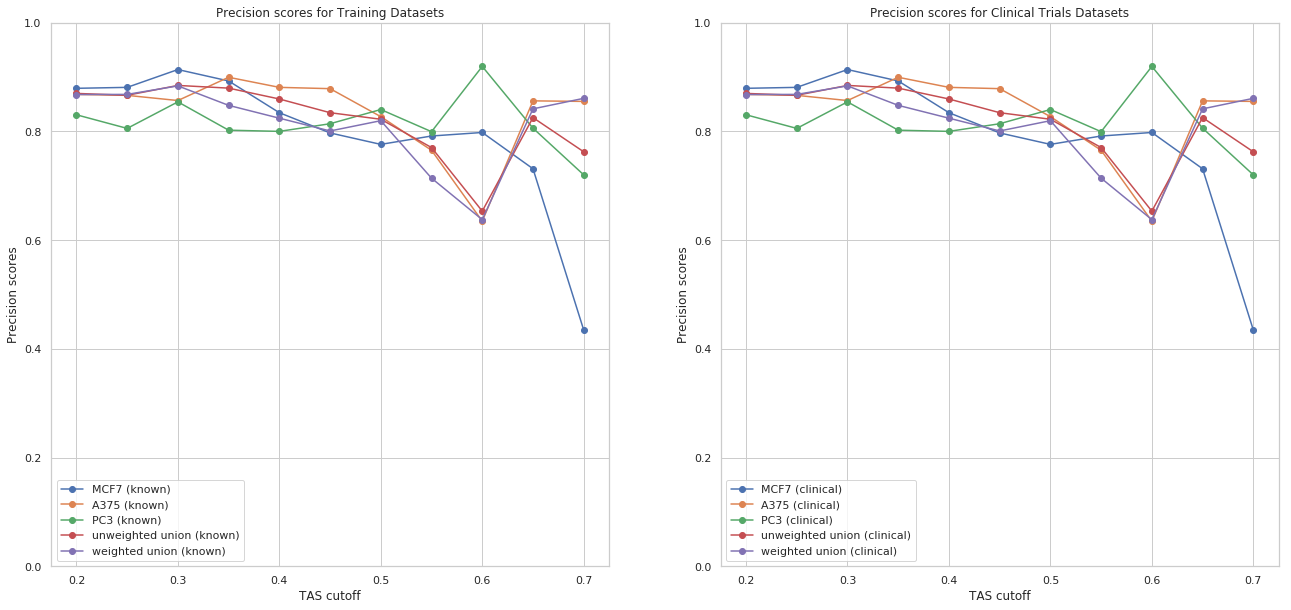

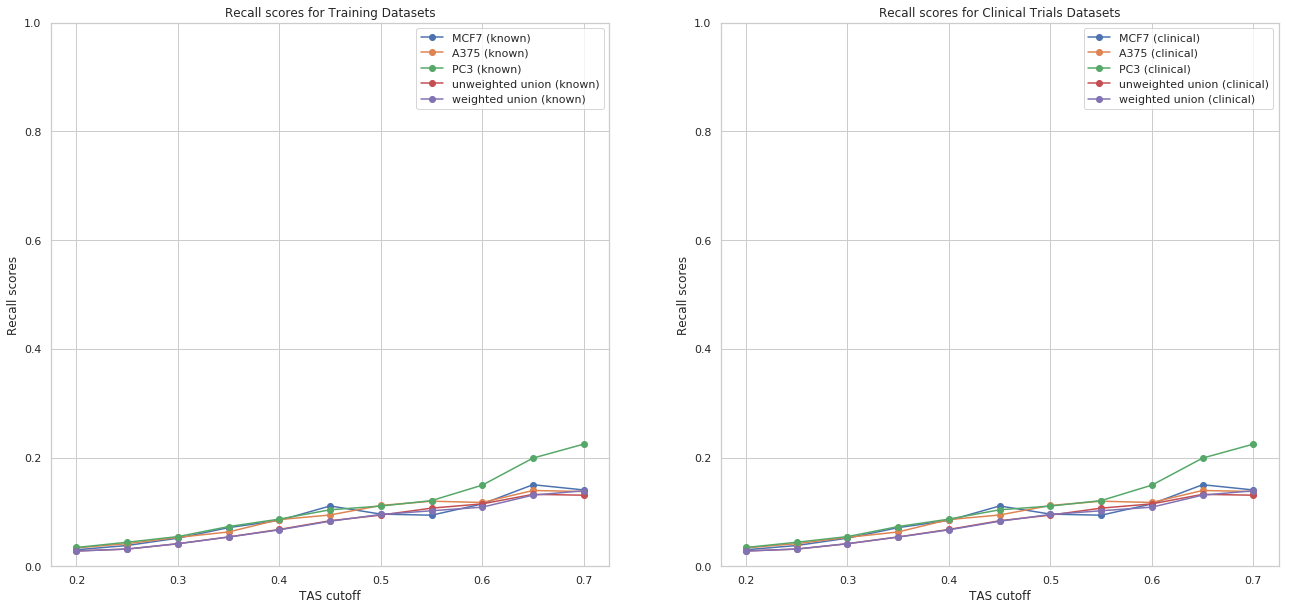

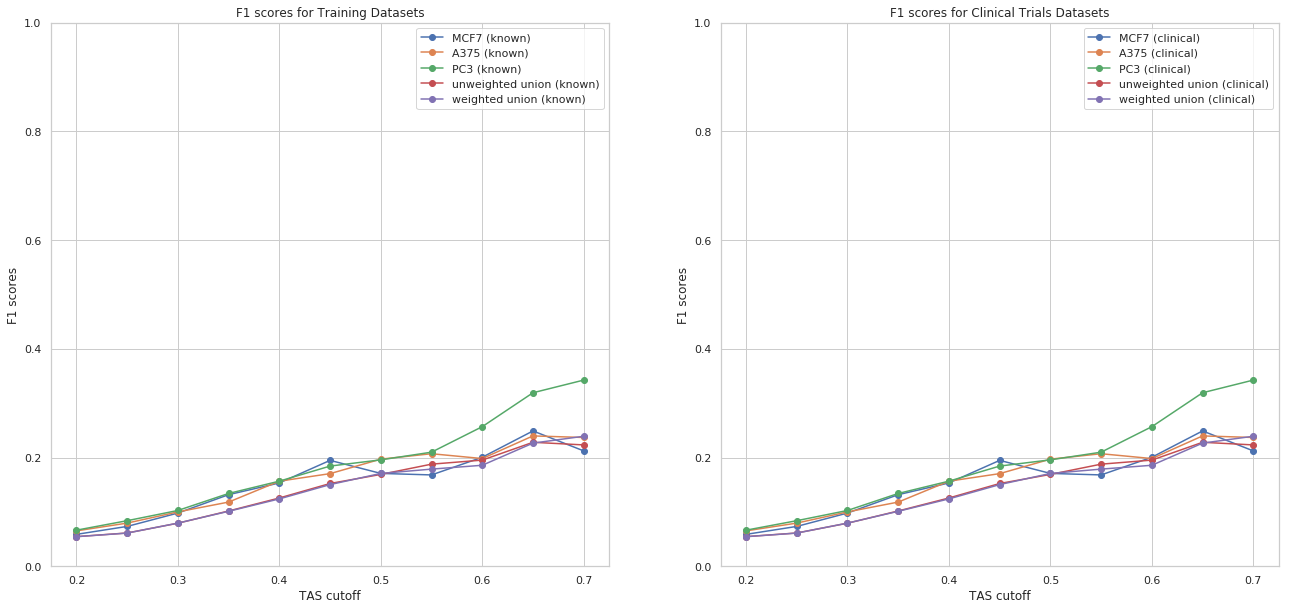

In [48]:
metrics = ['precision', 'recall', 'F1']
### for each metric,
for metric in metrics:
    ## generate a scatter plot showing the metrics across all models and tas cutoffs
    compare_metric(train_metrics, val_metrics, metric)